   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

D

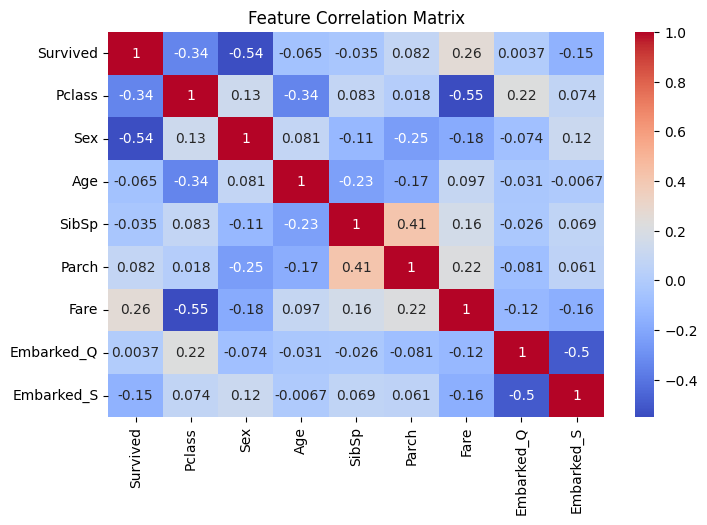

In [2]:
# ----------------------------------------
# Titanic Dataset Feature Engineering
# ----------------------------------------

# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load Dataset
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Step 3: Explore the Dataset
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Step 4: Handle Missing Data
# Fill missing 'Age' with median, and 'Embarked' with mode
age_imputer = SimpleImputer(strategy='median')
df['Age'] = age_imputer.fit_transform(df[['Age']])

embarked_imputer = SimpleImputer(strategy='most_frequent')
df['Embarked'] = embarked_imputer.fit_transform(df[['Embarked']]).flatten()

# Drop 'Cabin' as it has too many missing values
df.drop(columns=['Cabin'], inplace=True)

# Step 5: Encode Categorical Variables
label = LabelEncoder()
df['Sex'] = label.fit_transform(df['Sex'])  # male=1, female=0
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Step 6: Drop Irrelevant Columns
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

# Step 7: Feature Scaling
scaler = StandardScaler()
numeric_cols = ['Age', 'Fare']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Step 8: Feature Extraction (PCA)
X = df.drop(columns=['Survived'])
y = df['Survived']

pca = PCA(n_components=2)
pca_features = pca.fit_transform(X)
pca_df = pd.DataFrame(pca_features, columns=['PC1', 'PC2'])
print("\nExplained Variance Ratio by PCA:", pca.explained_variance_ratio_)

# Step 9: Feature Selection
selector = SelectKBest(score_func=f_classif, k=5)
fit = selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
print("\nTop 5 Selected Features:", selected_features.tolist())

# Step 10: Summary
print("\nDataset after preprocessing:")
print(df.head())

# Step 11: Visualize Correlation
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()